# Loi de Malus : sans le polariseur

In [1]:
import glob, os
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.io import fits
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator
from astropy.stats import sigma_clipped_stats
#import data_manage_lib as dml

%matplotlib widget

In [69]:
def get_colors(n_steps, cmap_name='Blues', vmin=0, vmax=None):
    if vmax is None:
        vmax = n_steps - 1
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)
    return [cmap(norm(i)) for i in range(n_steps)], norm, cmap

def has_key(hdul, key='THETA_R'):
    """Retourne True si THETA_R existe dans le header"""
    return key in hdul[0].header

def get_chi2(data, model, error):
    chi2 = np.sum((data - model)**2 / error**2)
    return chi2

def fold_angles_180(angles):
    """Fold angles to [-90, 90] range using 180° symmetry.
    Transforms angles so that 100° → 80°, 110° → 70°, etc.
    """
    angles = np.asarray(angles)
    # Fold angles > 90
    folded = np.where(angles > 90, 180 - angles, angles)
    # Fold angles < -90
    folded = np.where(folded < -90, -180 - folded, folded)
    return folded.tolist() if isinstance(angles, list) else folded

# Model function for fitting
def cos2(theta_R, theta_E, A):
    return A * np.cos(np.radians(theta_E - theta_R))**2

In [3]:
data_path = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/'
#data_path = "C:\\Users\\Administrator\\Documents\\Scripts_Commande_VNA\\CosmoCal_data\\"

plot_path = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Plots/'
#plot_path = "C:\\Users\\Administrator\\Documents\\Scripts_Commande_VNA\\Louise_dev\\Plots\\"
save_plots = True



# Premier essai mardi 17/02 : quelques points mesurés à vue

In [ ]:
S21 = np.array([-38, -38, -38.7, -39, -39.5, -40, -41.2, -43, -46.5, -52.3, -64.8, -52.4, -47.3, -47, -44.5, -41.2, -41.7, -39])
nmeas = np.size(S21)
angle = np.arange(nmeas)*10

plt.figure()
plt.plot(angle, 10**(S21/10), 'o')

### Première acquisiton mercredi 18/02 : un fichier pour chaque thetaR

In [ ]:
allthetaR = []
allmag = []

path_save2 = path_save + 'Malus_manual/'
os.chdir(path_save2)

i = 0
for file in glob.glob("*thetaR*.fits"):
    print(i)
    print(file)
    hdul = fits.open(path_save2 + file)
    header = hdul[0].header
    thetaR = header['THETA_R']
    allthetaR.append(thetaR)
    mag = hdul[0].data  # Access magnitude
    print(mag.shape)
    allmag.append(mag)
    i+=1

allthetaR = np.array(allthetaR)
allmag = np.array(allmag)
print(allmag.shape)

In [ ]:
ff = 10
colors, norm, cmap = get_colors(ff, cmap_name='viridis', vmin=0, vmax=ff-1)
trace = 0 # S21
plt.figure()
for f in range(ff):
    plt.plot(allthetaR[1:-2], 10**(allmag[1:-2, trace, f]/10), 'o', color=colors[f])

# Nouvelle optimisation : 1 seul fichier

On stop le script pour tourner thetaR 

In [107]:
# Get data from one file
scan = '20260316_172532'
#scan = '20260316_155421'
hdul = fits.open(data_path + f"Malus_{scan}.fits")
header = hdul[0].header
hdul.info()  # View structure

freq_samples = hdul[0].data * 1e-9  # Access frequency samples (convert to GHz)
mag = hdul[1].data  # Access magnitude
mag_lin = 10**(mag/10)

nthetaR, nS, nfreqs = mag_lin.shape

traces = ['S21', 'S12', 'S11', 'S22']


print(f"Frequency samples: {freq_samples}")

fstart_ind = np.argwhere(freq_samples > 130)[0][0]
print(f"First frequency sample above 130 GHz is at index {fstart_ind}, corresponding to {freq_samples[fstart_ind]:.2f} GHz")


# Pour les premiers runs, THETA_R n'était pas sauvegardé
if has_key(hdul, key='THETA_R'):
    thetaR = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 
             0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120] # in degree

print(f"thetaR: {thetaR}")

header

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Malus_20260316_172532.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (242,)   float64   
  1  MAGNITUDE     1 ImageHDU        10   (242, 4, 26)   float64   
  2  PHASE         1 ImageHDU        10   (242, 4, 26)   float64   
Frequency samples: [110.         110.24896266 110.49792531 110.74688797 110.99585062
 111.24481328 111.49377593 111.74273859 111.99170125 112.2406639
 112.48962656 112.73858921 112.98755187 113.23651452 113.48547718
 113.73443983 113.98340249 114.23236515 114.4813278  114.73029046
 114.97925311 115.22821577 115.47717842 115.72614108 115.97510373
 116.22406639 116.47302905 116.7219917  116.97095436 117.21991701
 117.46887967 117.71784232 117.96680498 118.21576764 118.46473029
 118.71369295 118.9626556  119.21161826 119.46058091 119.70954357
 119.95850622 120.20746888 120.45643154 120.70539419 120.95435685
 121.2033195  121.45228216 12

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =                  242                                                  
EXTEND  =                    T                                                  
DATATYPE= 'Frequency samples in GHz'                                            
THETA_R = '[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 0, -10, &'    
CONTINUE  '-20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120]'           
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                  242                                                  
IFBW    =                 1000                                                  
TRACES  = 'S21, S12, S11, S2

In [108]:
# Get data from a second file
hdul2 = fits.open(data_path + "Malus_20260316_164516.fits")
header = hdul2[0].header
hdul2.info()  # View structure
mag2 = hdul2[1].data  # Access magnitude
mag2_lin = 10**(mag2/10)

if has_key(hdul2, key='THETA_R'):
    thetaR2 = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR2 = [-30, 0, 30] # in degree

print(f"thetaR2: {thetaR2}")

header

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Malus_20260316_164516.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (242,)   float64   
  1  MAGNITUDE     1 ImageHDU        10   (242, 4, 5)   float64   
  2  PHASE         1 ImageHDU        10   (242, 4, 5)   float64   
thetaR2: [-90, -45, 0, 45, 90]


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =                  242                                                  
EXTEND  =                    T                                                  
DATATYPE= 'Frequency samples in GHz'                                            
THETA_R = '[-90, -45, 0, 45, 90]'                                               
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                  242                                                  
IFBW    =                 1000                                                  
TRACES  = 'S21, S12, S11, S22'                                                  
TIMESTAM= '2026-03-16T16:46:

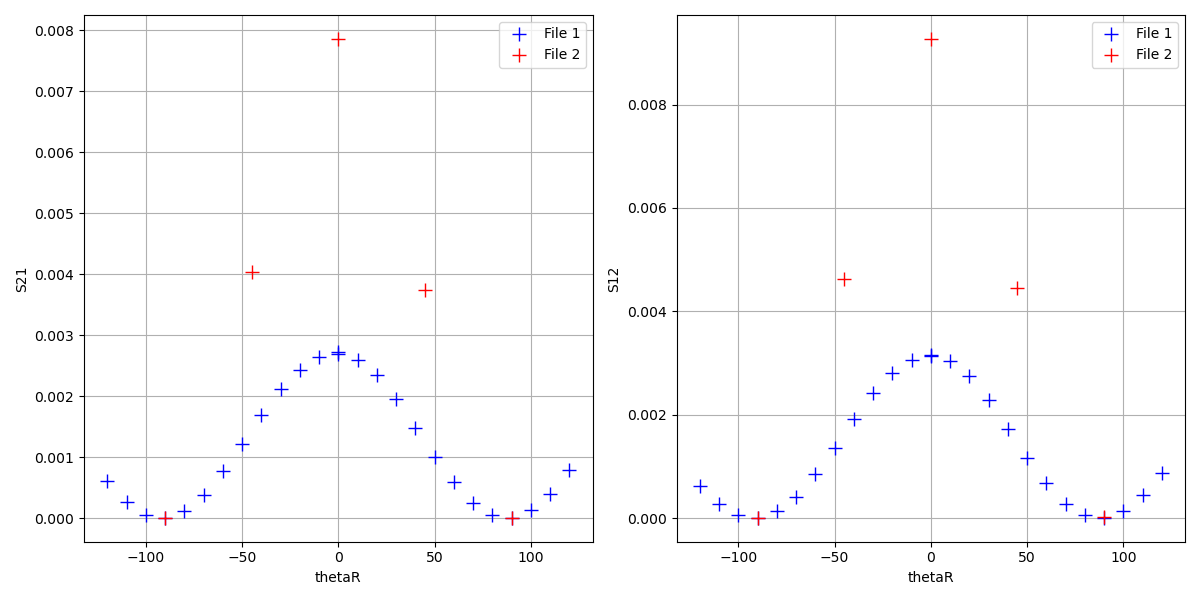

In [109]:
# Plot the mean S21 and S12 for both files
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()

# S21
axs[0].plot(thetaR, np.mean(mag_lin[:, 0, :], axis=1), 'b+', ms=10, label='File 1')
axs[0].plot(thetaR2, np.mean(mag2_lin[:, 0, :], axis=1), 'r+', ms=10, label='File 2')
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('S21')
axs[0].legend()

#S12
axs[1].plot(thetaR, np.mean(mag_lin[:, 1, :], axis=1), 'b+', ms=10, label='File 1')
axs[1].plot(thetaR2, np.mean(mag2_lin[:, 1, :], axis=1), 'r+', ms=10, label='File 2')
axs[1].set_xlabel('thetaR')
axs[1].set_ylabel('S12')
axs[1].legend()

axs[0].grid()
axs[1].grid()

fig.tight_layout()



81 242


/tmp/ipykernel_5289/562452169.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


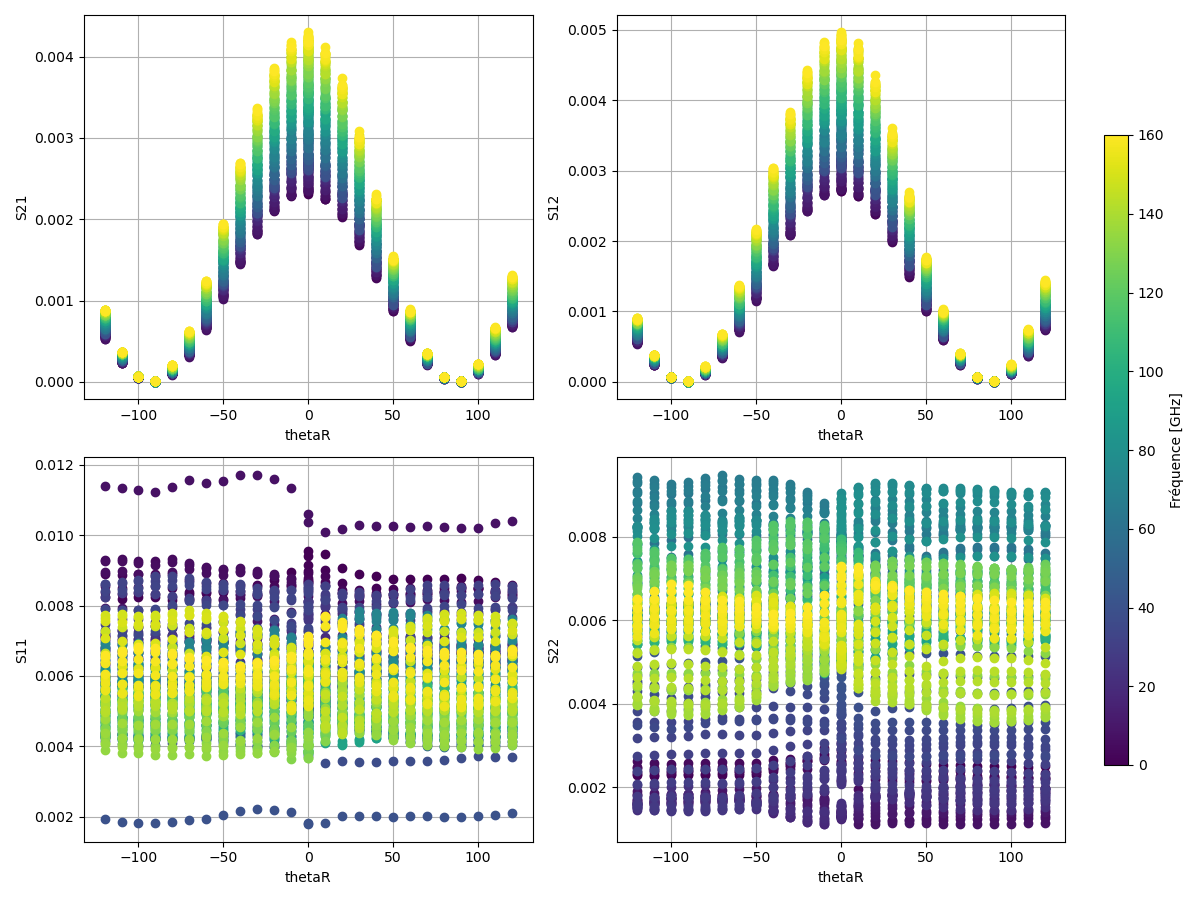

In [110]:
# Plot each frequency separately
freqs = np.arange(fstart_ind, nfreqs)
print(fstart_ind, nfreqs)
colors, norm, cmap = get_colors(len(freqs), cmap_name='viridis', vmin=0, vmax=len(freqs)-1)

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs = axs.ravel()
for t in range(4):
    #axs[t].set_title(f"{traces[t]}")
    for f, freq in enumerate(freqs):
        axs[t].plot(thetaR, mag_lin[:, t, freq], 'o', color=colors[f])
    #axs[0].plot(thetaR2, mag2_lin[:, 0, freq], 'r+', ms=10)
    axs[t].set_xlabel('thetaR')
    axs[t].set_ylabel(f"{traces[t]}")
    #axs[t].set_yscale('log')
    axs[t].grid()

# créer une seule colorbar pour tous les plots
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Fréquence [GHz]')


fig.tight_layout(rect=[0, 0, 0.9, 1])

if save_plots:
    fig.savefig(plot_path + f"Malus_{scan}_allfrequencies.png", dpi=300)

# Ajustement par fréquence sans barre d'erreur

In [111]:
np.argsort(thetaR)

array([25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14,  0, 13,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12])

Fitting without error bars


/tmp/ipykernel_5289/2178075420.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


chi2 red mean: 1.0994016930083346
ThetaE moyen : -2.1560219022800093
Écart-type de thetaE : 0.39283466683363055
Erreur sur thetaE 0.005241391779432573


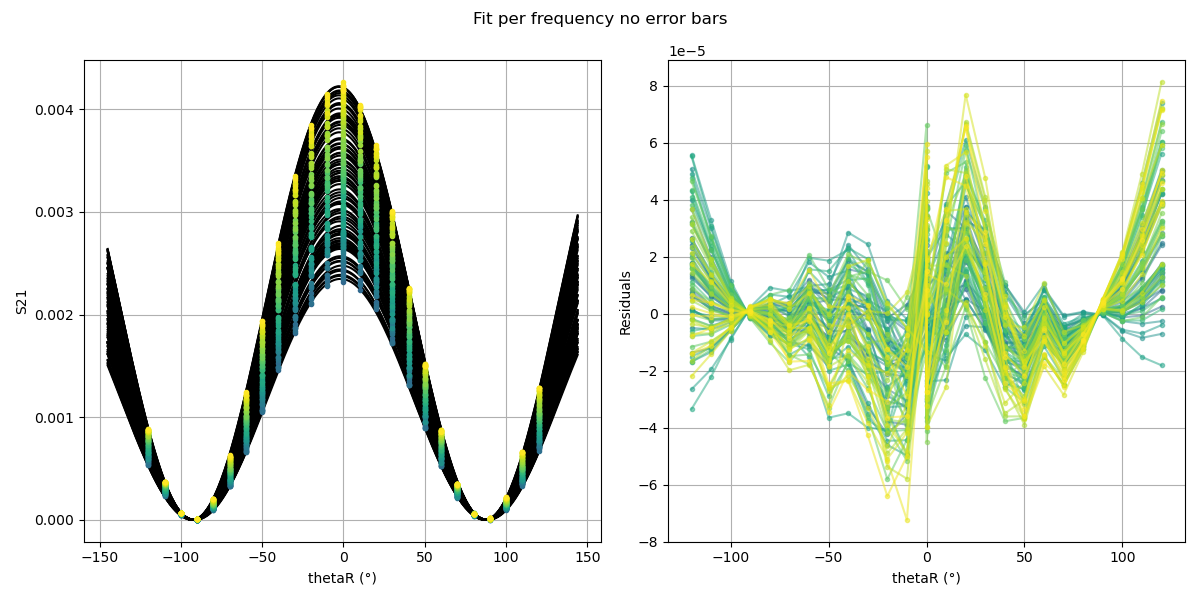

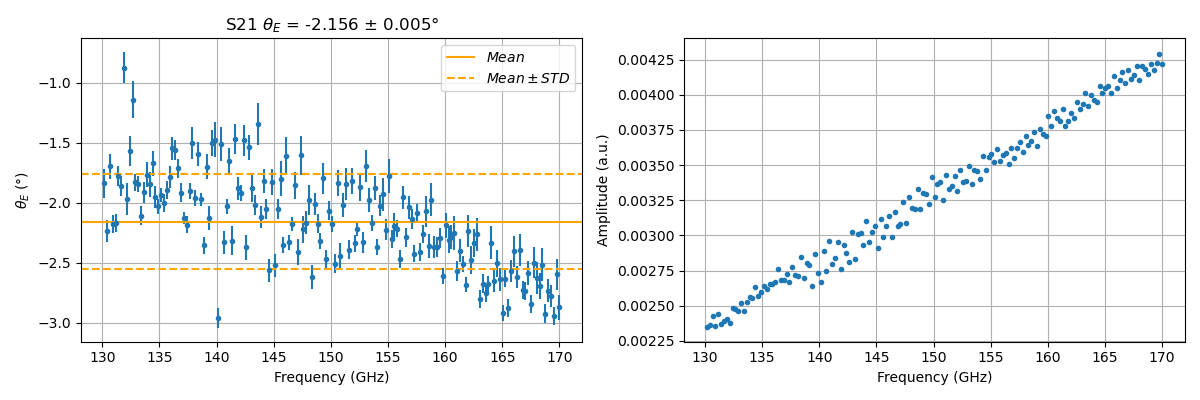

In [116]:
#### Sans donner d'erreur à curve_fit, mais en calculant le chi2 avec les erreurs estimées à partir du STD des résidus
print("Fitting without error bars")
# Loop over frequencies
t = 0 # trace index (S21 or S12)

tt = np.arange(-145, 145, 1)

allthetaE = []
allamp = []
allthetaE_err = []
allamp_err = []
allchi2_red = []


fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
fig.suptitle(r"Fit per frequency no error bars")
norm = Normalize(vmin=freq_samples.min(), vmax=freq_samples.max())
cmap = plt.cm.get_cmap('viridis')

for f in range(fstart_ind, nfreqs):
    signal = mag_lin[:, 0, f]

    # Fit the data
    popt, pcov = curve_fit(cos2, thetaR, signal)
    error = np.sqrt(np.diag(pcov))

    allthetaE.append(popt[0])
    allthetaE_err.append(error[0])

    allamp.append(popt[1])
    allamp_err.append(error[1])

    # Residus et chi2
    residuals = signal - cos2(thetaR, *popt)
    std_res = np.std(residuals)
    chi2 = get_chi2(signal, cos2(thetaR, *popt), std_res)

    chi2_red = chi2 / (len(thetaR) - len(popt))
    allchi2_red.append(chi2_red)

    if f in range(fstart_ind, nfreqs, 2): # indices des fréquences à afficher
        color = cmap(norm(freq_samples[f]))
        axs[0].errorbar(thetaR, signal, yerr=None, marker='.', ls='None', color=color)
        axs[0].plot(tt, cos2(tt, *popt), 'k', label='Fit cos^2')
        axs[1].plot(np.sort(thetaR), residuals[np.argsort(thetaR)], '.-', label=f"{freq_samples[f]:.1f}", color=color, alpha=0.5)
        
axs[0].set_xlabel("thetaR (°)")
axs[0].set_ylabel(f"{traces[t]}")
axs[0].grid(10)

axs[1].set_xlabel("thetaR (°)")
axs[1].set_ylabel("Residuals")
axs[1].grid(10)

fig.tight_layout()

if save_plots:
    fig.savefig(plot_path + f"Malus_Scan{scan}_Fit_per_freq_no_errors_{traces[t]}.png", dpi=300)

allthetaE = np.array(allthetaE)
allthetaE_err = np.array(allthetaE_err)
allamp = np.array(allamp)
allamp_err = np.array(allamp_err)
allchi2_red = np.array(allchi2_red)

print("chi2 red mean:", np.mean(allchi2_red))

mthetaE = np.mean(allthetaE)
print("ThetaE moyen :", mthetaE)
stdthetaE = np.std(allthetaE) #/ np.sqrt(nfreqs)
print("Écart-type de thetaE :", stdthetaE)

# Erreur sur la moyenne de thetaE
erreur = np.sqrt(np.sum(allthetaE_err**2 )) / nfreqs
print('Erreur sur thetaE', erreur)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs = axs.ravel()
axs[0].errorbar(freq_samples[fstart_ind:nfreqs], allthetaE, yerr=allthetaE_err, fmt='.')
axs[0].axhline(mthetaE, color='orange', label=r'$Mean$')
axs[0].axhline(mthetaE-stdthetaE, color='orange', ls='--')
axs[0].axhline(mthetaE+stdthetaE, color='orange', label=r'$Mean \pm STD$', ls='--')
axs[0].set_xlabel("Frequency (GHz)")
axs[0].set_ylabel(r'$\theta_E$ (°)')
axs[0].set_title(rf'{traces[t]} $\theta_E$ = {mthetaE:.3f} ± {erreur:.3f}°')
axs[0].grid(10)
axs[0].legend()

axs[1].errorbar(freq_samples[fstart_ind:nfreqs], allamp, yerr=allamp_err, fmt='.')
axs[1].set_xlabel("Frequency (GHz)")
axs[1].set_ylabel(r'Amplitude (a.u.)')
axs[1].grid(10)

fig.tight_layout()

if save_plots:
    fig.savefig(plot_path + f"Malus_Scan{scan}_Fit_per_freq_no_errors_thetaE_{traces[t]}.png", dpi=300)

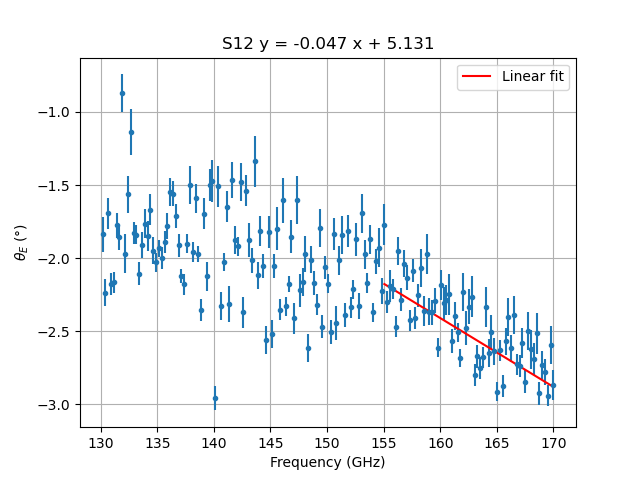

In [115]:
def linear_model(x, a, b):
    return a * x + b

ind_cut = 100
popt, pcov = curve_fit(linear_model, freq_samples[fstart_ind+ind_cut:nfreqs], allthetaE[ind_cut:], sigma=allthetaE_err[ind_cut:], absolute_sigma=True)
afit, bfit = popt

plt.figure()
plt.errorbar(freq_samples[fstart_ind:nfreqs], allthetaE, yerr=allthetaE_err, fmt='.')
plt.plot(freq_samples[fstart_ind+ind_cut:nfreqs], linear_model(freq_samples[fstart_ind+ind_cut:nfreqs], *popt), 'r-', label='Linear fit')
plt.xlabel("Frequency (GHz)")
plt.ylabel(r'$\theta_E$ (°)')
plt.title(rf'{traces[t]} y = {afit:.3f} x + {bfit:.3f}')
plt.grid(10)
plt.legend()
plt.show()

# Estimation des erreurs

On a fait 5 scans identiques avec alpha = [-90, -90, -45, 0, 45, 90, 90]

In [47]:
allthetaR = []
allmag = []

os.chdir(data_path)

i = 0
for file in glob.glob("Malus_20260316_16*.fits"):
    #if i>0:
    print(i)
    print(file)
    hdul = fits.open(data_path + file)
    header = hdul[0].header
    allthetaR.append(ast.literal_eval(header['THETA_R']))
    mag = hdul[1].data  # Access magnitude
    print(mag.shape)
    allmag.append(mag)
    i+=1

allmag = np.array(allmag)
allthetaR = np.array(allthetaR)
print(allmag.shape)

allmag_lin = 10**(allmag/10)

nscans, nthetaR, nS, nfreqs = allmag_lin.shape

0
Malus_20260316_163729.fits
(5, 4, 242)
1
Malus_20260316_164516.fits
(5, 4, 242)
2
Malus_20260316_163416.fits
(5, 4, 242)
3
Malus_20260316_164231.fits
(5, 4, 242)
4
Malus_20260316_163948.fits
(5, 4, 242)
(5, 5, 4, 242)


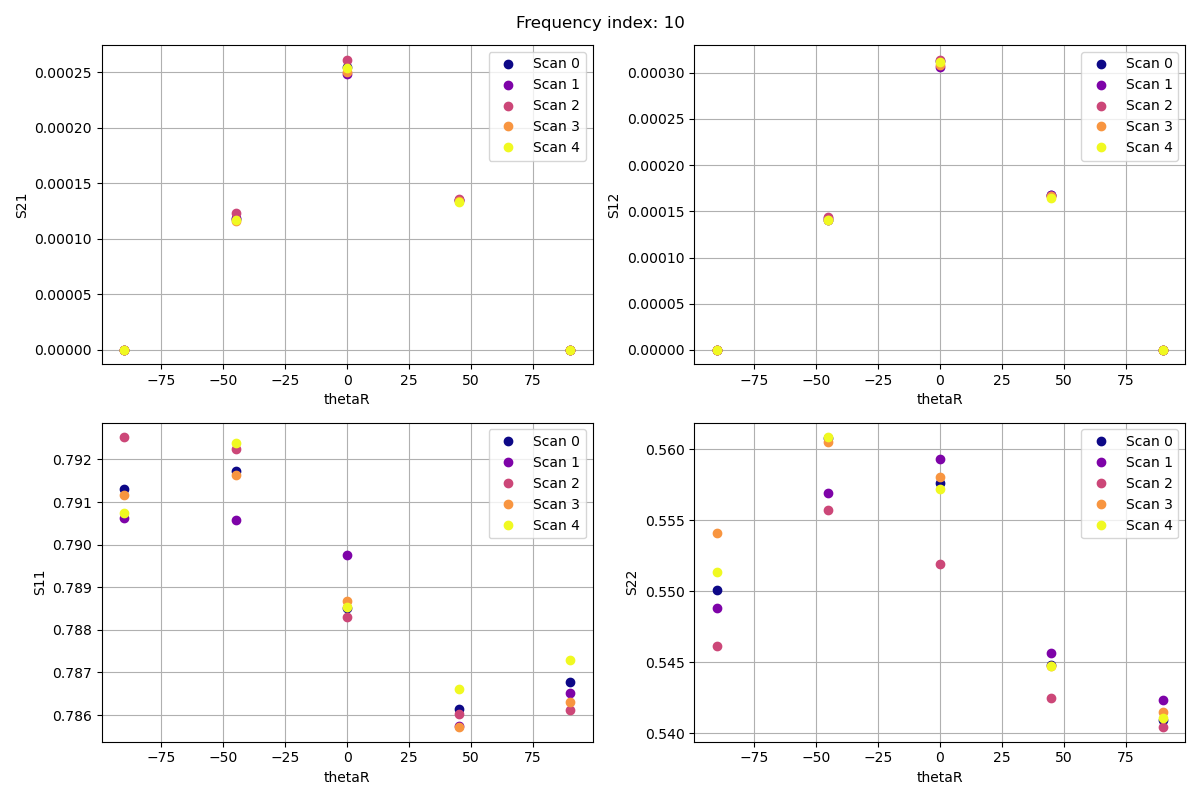

In [48]:
# Plot each frequency separately (avec les 5 scans)
freqs = [10] # indice de la frequence
colors, norm, cmap = get_colors(nscans, cmap_name='plasma', vmin=0, vmax=nscans-1)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for t in range(4):
    for m in range(nscans):
            for i, f in enumerate(freqs):
                axs[t].plot(allthetaR[m], allmag_lin[m, :, t, f], 'o', color=colors[m], label=f'Scan {m}')
    axs[t].set_xlabel('thetaR')
    axs[t].set_ylabel(f"{traces[t]}")
    axs[t].grid()
    axs[t].legend()

fig.suptitle(f'Frequency index: {freqs[0]}')
fig.tight_layout()

if save_plots:
    fig.savefig(plot_path + f"Malus_16-03_ 5scans.png", dpi=300)

In [49]:
# Mean and STD sur les 5 scans
mean_over_scans = np.mean(allmag_lin, axis=0)
std_over_scans = np.std(allmag_lin, axis=0) # [nangle, nS, nfreq]

print(mean_over_scans.shape)

(5, 4, 242)


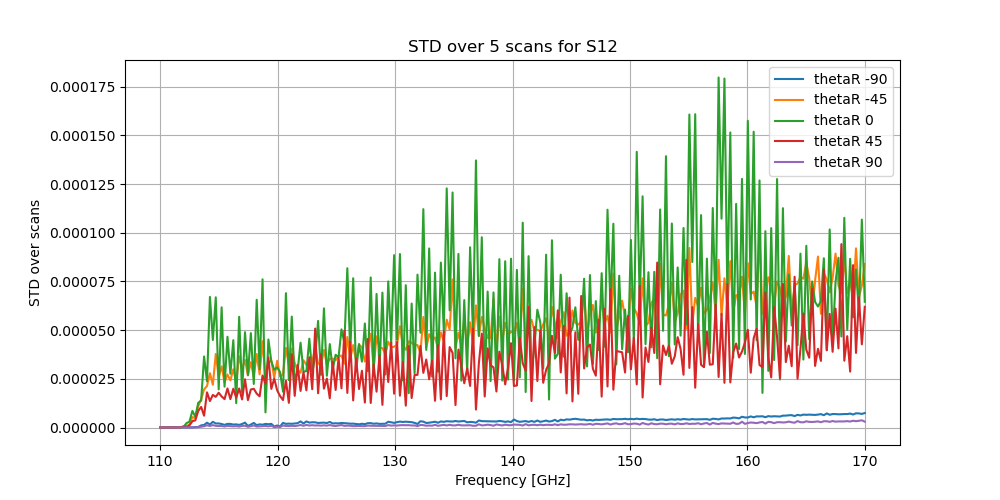

In [53]:
# STD sur les 5 scans en fonction de thetaR et de la frequence
# On voit que le STD est plus grand pour les angles 0 et +-45 que pour les angles +-90°.
# Pour thetaR = 90, les cornets sont croisés => pas de signal. Le STD a l'air de suivre l'amplitude du signal.
t = 1 # S21 ou S12

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
for a in range(nthetaR): # pour chaque angle
    axs.plot(freq_samples, std_over_scans[a, t, :], label=f'thetaR {allthetaR[0][a]}')
axs.set_xlabel('Frequency [GHz]')
axs.set_ylabel('STD over scans')
axs.legend()
axs.grid()
axs.set_title(f'STD over 5 scans for {traces[t]}')

if save_plots:
    fig.savefig(plot_path + f"Malus_16-03_ STD_over_5scans.png", dpi=300)


(5, 4)


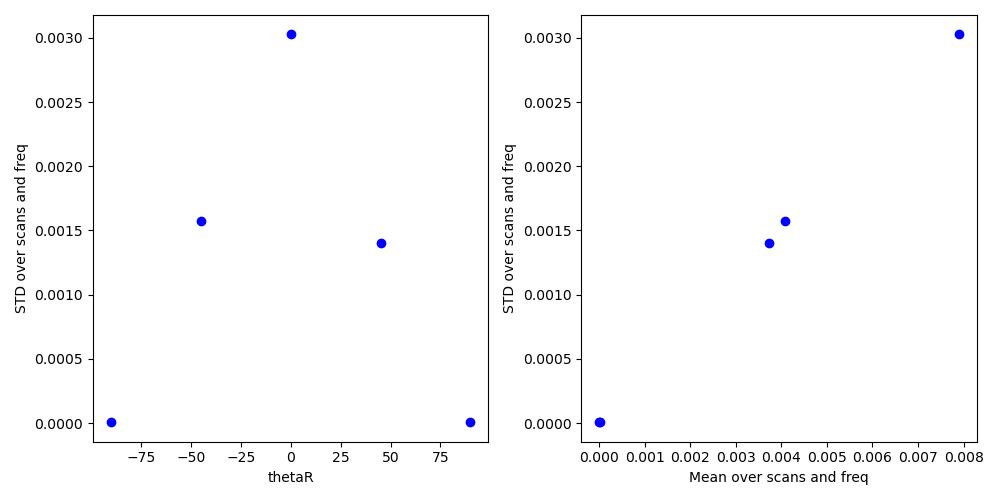

In [51]:
mean_over_scansfreq = np.mean(allmag_lin, axis=(0, 3))
std_over_scansfreq = np.std(allmag_lin, axis=(0, 3)) # [nangle, nS]

print(mean_over_scansfreq.shape)

t = 0
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(allthetaR[0], std_over_scansfreq[:, t], 'bo')
axs[0].set_xlabel('thetaR')
axs[0].set_ylabel('STD over scans and freq')

# STD en fonction de l'amplitude moyenne du signal
axs[1].plot(mean_over_scansfreq[:, t], std_over_scansfreq[:, t], 'bo')
axs[1].set_xlabel('Mean over scans and freq')
axs[1].set_ylabel('STD over scans and freq')

fig.tight_layout()

Fitted parameter a: 3.82e-01


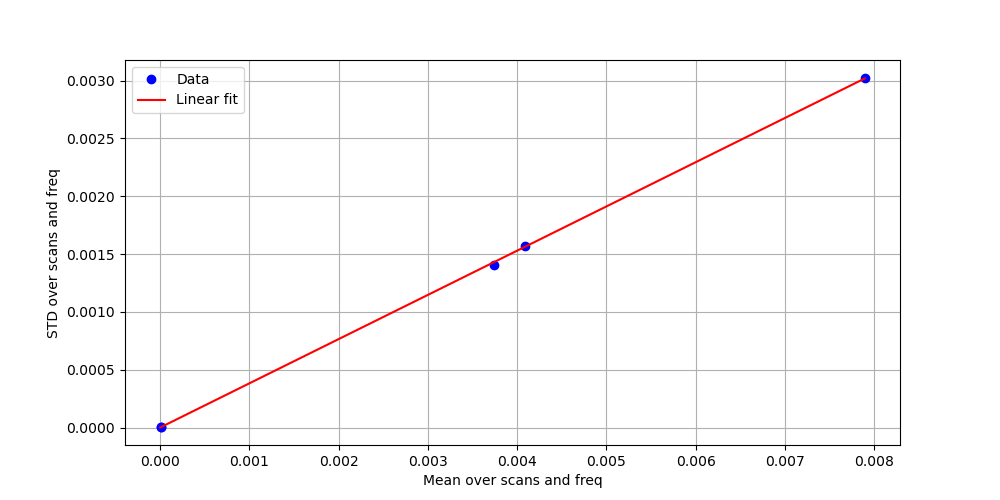

In [13]:
# On voit que le STD a l'air d'être proportionnel à l'amplitude du signal, ce qui suggère que le bruit est multiplicatif 
# Faisons un ajustement linéaire du STD en fonction de la moyenne pour vérifier cela
def linear_model(x, a):
    return a * x
popt, pcov = curve_fit(linear_model, mean_over_scansfreq[:, t], std_over_scansfreq[:, t])
a_fit = popt[0]
print(f"Fitted parameter a: {a_fit:.2e}")

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(mean_over_scansfreq[:, t], std_over_scansfreq[:, t], 'bo', label='Data')
x_fit = np.linspace(0, np.max(mean_over_scansfreq[:, t]), 100)
axs.plot(x_fit, linear_model(x_fit, *popt), 'r-', label='Linear fit')
axs.set_xlabel('Mean over scans and freq')
axs.set_ylabel('STD over scans and freq')
axs.legend()
axs.grid()
#chi2 = get_chi2(std_over_scansfreq[:, t], linear_model(mean_over_scansfreq[:, t], *popt), std_over_scansfreq[:, t])
#print("Chi2 :", chi2)

#chi2_red = chi2 / (len(thetaR) - len(popt))
#print("Chi2 réduit :", chi2_red)

[ 3.11959187e-05  1.01699020e-04  1.72202121e-04  2.42705223e-04
  3.13208324e-04  3.83711425e-04  4.54214526e-04  5.24717628e-04
  5.95220729e-04  6.65723830e-04  7.36226932e-04  8.06730033e-04
  8.77233134e-04  9.47736235e-04  1.01823934e-03  1.08874244e-03
  1.15924554e-03  1.22974864e-03  1.30025174e-03  1.37075484e-03
  1.44125794e-03  1.51176105e-03  1.58226415e-03  1.65276725e-03
  1.72327035e-03  1.79377345e-03  1.86427655e-03  1.93477965e-03
  2.00528275e-03  2.07578586e-03  2.14628896e-03  2.21679206e-03
  2.28729516e-03  2.35779826e-03  2.42830136e-03  2.49880446e-03
  2.56930757e-03  2.63981067e-03  2.71031377e-03  2.78081687e-03
  2.85131997e-03  2.92182307e-03  2.99232617e-03  3.06282927e-03
  3.13333238e-03  3.20383548e-03  3.27433858e-03  3.34484168e-03
  3.41534478e-03  3.48584788e-03  3.48318750e-03  3.40736364e-03
  3.33153977e-03  3.25571591e-03  3.17989205e-03  3.10406818e-03
  3.02824432e-03  2.95242046e-03  2.87659659e-03  2.80077273e-03
  2.72494887e-03  2.64912

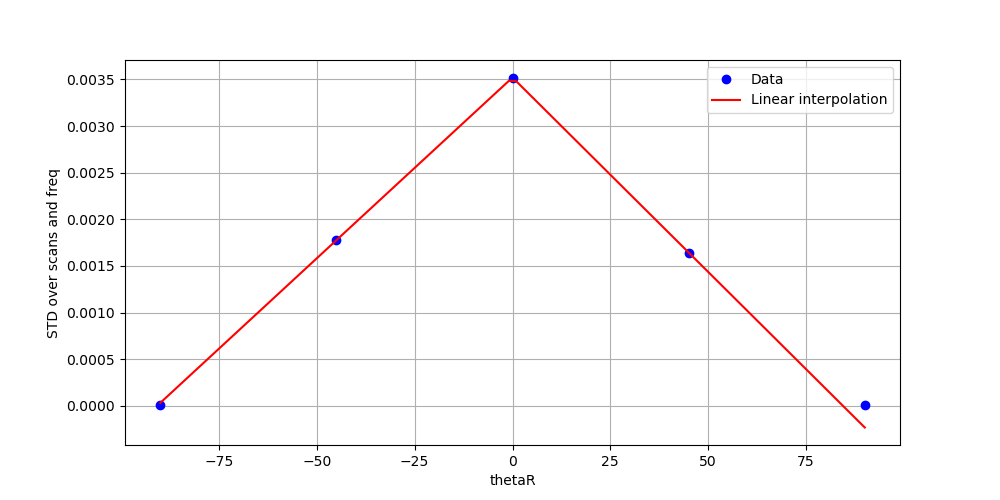

In [55]:
# On interpole le STD en fonction de thetaR pour avoir un modèle d'erreurs en fonction de thetaR
from scipy.interpolate import interp1d
interp_func = interp1d(allthetaR[0][1:-1], std_over_scansfreq[:, t][1:-1], kind='linear', fill_value='extrapolate')

#thetaR_interp = np.linspace(np.min(allthetaR[0][1:-1]), np.max(allthetaR[0][1:-1]), 100)
thetaR_interp = np.linspace(np.min(allthetaR[0]), np.max(allthetaR[0]), 100)

std_interp = interp_func(thetaR_interp) 
print(std_interp)

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(allthetaR[0], std_over_scansfreq[:, t], 'bo', label='Data')
axs.plot(thetaR_interp, std_interp, 'r-', label='Linear interpolation')
axs.set_xlabel('thetaR')
axs.set_ylabel('STD over scans and freq')
axs.legend()
axs.grid()

### Deux mesures successives sans rien changer

In [ ]:
t = 0

m90a = allmag_lin[:,0,t,:]
m90b = allmag_lin[:,1,t,:]

p90a = allmag_lin[:,5,t,:]
p90b = allmag_lin[:,6,t,:]


diff_p90 = p90a - p90b
diff_m90 = m90a - m90b

print(diff_p90.shape)

mean_p90, median_p90, stddev_p90 = sigma_clipped_stats(diff_p90, sigma=2)
print(mean_p90, median_p90, stddev_p90)

mean_m90, median_m90, stddev_m90 = sigma_clipped_stats(diff_m90, sigma=2)
print(mean_m90, median_m90, stddev_m90)


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex='col')
axs = axs.ravel()

m = 2 # indice du scan

axs[0].plot(m90a[m, :], label='m90a')
axs[0].plot(m90b[m, :], label='m90b')
#axs[0].set_xlabel('Frequency index')
axs[0].set_ylabel('Minus 90')
axs[0].legend()
axs[0].xaxis.set_major_locator(MultipleLocator(10))
axs[0].grid(which='major', alpha=0.8)

axs[1].plot(p90a[m, :], label='p90a')
axs[1].plot(p90b[m, :], label='p90b')
#axs[1].set_xlabel('Frequency index')
axs[1].set_ylabel(' Plus 90')
axs[1].legend()
axs[1].xaxis.set_major_locator(MultipleLocator(10))
axs[1].grid(which='major', alpha=0.8)

axs[2].plot(diff_m90[m, :])
axs[2].set_xlabel('Frequency index')
axs[2].set_ylabel(' Difference Minus 90')
axs[2].xaxis.set_major_locator(MultipleLocator(10))
axs[2].grid(which='major', alpha=0.8)

axs[3].plot(diff_p90[m, :])
axs[3].set_xlabel('Frequency index')
axs[3].set_ylabel(' Difference Plus 90')
axs[3].xaxis.set_major_locator(MultipleLocator(10))
axs[3].grid(which='major', alpha=0.8)

fig.subplots_adjust(hspace=0)

# Ajustement

In [56]:
# Get data from one file
hdul = fits.open(data_path + "Malus_20260316_155421.fits")
header = hdul[0].header
hdul.info()  # View structure
mag = hdul[1].data  # Access magnitude
mag_lin = 10**(mag/10)

if has_key(hdul, key='THETA_R'):
    thetaR = ast.literal_eval(header['THETA_R'])
else:
    print("THETA_R not found in header, using default values.")
    thetaR = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 
             0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120] # in degree

print(f"thetaR: {thetaR}")

header

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Malus_20260316_155421.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (242,)   float64   
  1  MAGNITUDE     1 ImageHDU        10   (242, 4, 30)   float64   
  2  PHASE         1 ImageHDU        10   (242, 4, 30)   float64   
thetaR: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140]


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =                  242                                                  
EXTEND  =                    T                                                  
DATATYPE= 'Frequency samples in GHz'                                            
THETA_R = '[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, &'  
CONTINUE  '0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, &' 
CONTINUE  '-130, -140]'                                                         
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                  242                                                  
IFBW    =                 10

### Ajustement de la moyenne

In [58]:
interp_func(np.mod(thetaR, 90))
print(thetaR)
print(fold_angles_180(thetaR))

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 0, -10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140]
[  0  10  20  30  40  50  60  70  80  90  80  70  60  50  40   0 -10 -20
 -30 -40 -50 -60 -70 -80 -90 -80 -70 -60 -50 -40]


Fitting with error bars...
Paramètres optimisés : [-2.61598655  0.00781563]
Erreurs sur les paramètres : [9.28423616e-02 4.73884504e-05]
Écart-type des résidus : 7.681777851833252e-05
Chi2 : 14.604363391254163
Chi2 réduit : 0.5215844068305058


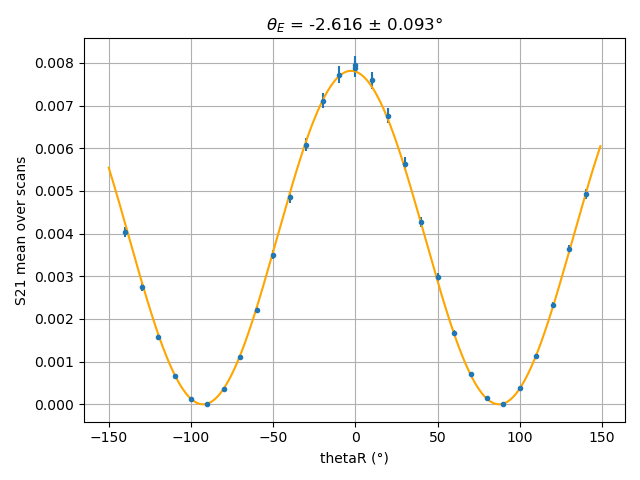

In [60]:
### Avec barres d'erreur
print("Fitting with error bars...")
t = 0 # trace index (S21 or S12)
tt = np.arange(-150, 150, 1)

signal = np.mean(mag_lin[:, 0, :], axis=1)
sigma = interp_func(fold_angles_180(thetaR)) / np.sqrt(nfreqs) # Erreur sur la moyenne en fonction de thetaR
#print(sigma)

# Fit the data
popt, pcov = curve_fit(cos2, thetaR, signal, sigma=sigma, absolute_sigma=True)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos2(thetaR, *popt)

std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)

chi2 = get_chi2(signal, cos2(thetaR, *popt), sigma)
print("Chi2 :", chi2)
chi2_red = chi2 / (len(thetaR) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(thetaR, signal, yerr=np.abs(sigma), marker='.', ls='None')
plt.plot(tt, cos2(tt, *popt), 'orange', label='Fit cos^2')
plt.xlabel("thetaR (°)")
plt.ylabel("S21 mean over scans")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)

plt.tight_layout()

### Ajustement par fréquence

Fitting without error bars


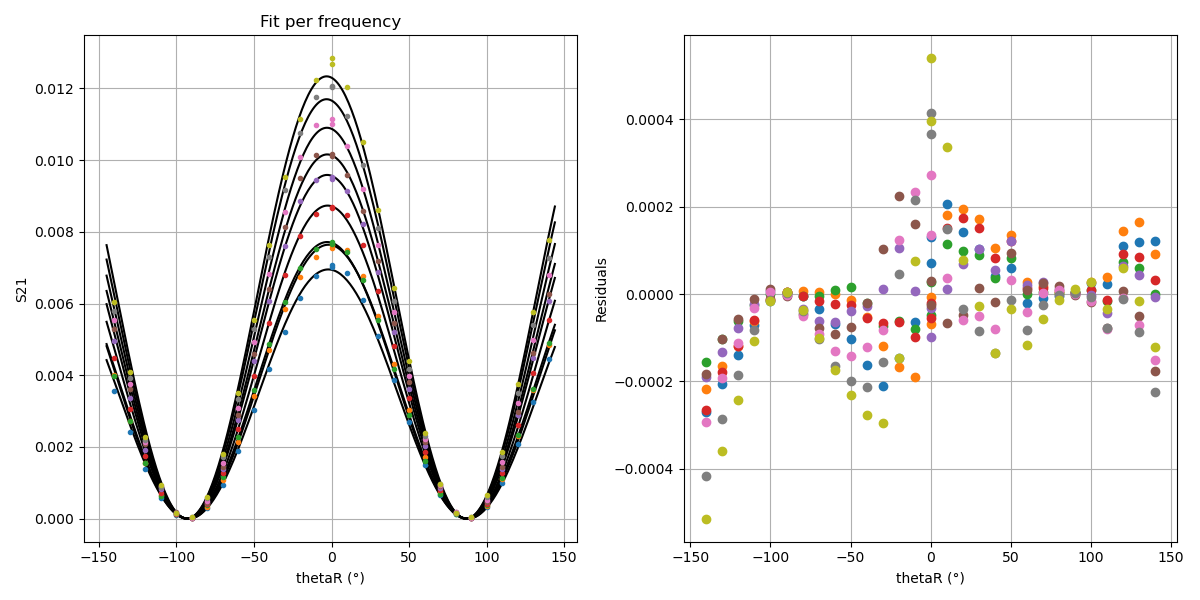

Fitting with error bars
All chi2 reduits [0.01485366 0.00704813 0.01001493 0.00842501 0.01187697 0.00734242
 0.01077777 0.00907001 0.01268094 0.00701896 0.01481444 0.00931947
 0.01136731 0.00880038 0.0140103  0.00956332 0.0144433  0.00928421
 0.02191275 0.01203214 0.01586792 0.01301156 0.0152952  0.01014553
 0.01650844 0.01312398 0.01750161 0.01063775 0.02371046 0.01322383
 0.01335833 0.01380309 0.0169927  0.0112796  0.01815462 0.01309098
 0.01635421 0.01177917 0.01880397 0.01391509 0.01003874 0.01228403
 0.02070331 0.01215434 0.01782735 0.0166201  0.0134299  0.01380544
 0.01559077 0.0157656  0.01385681 0.01357471 0.02178972 0.01641164
 0.01616941 0.01903471 0.0177774  0.01590484 0.01945025 0.01951471
 0.01779636 0.01852816 0.02255427 0.02283285 0.01527807 0.02147088
 0.01978471 0.01678962 0.01859184 0.02224425 0.01677249 0.01951592
 0.01993982 0.02570527 0.01463738 0.02326957 0.02219893 0.01850926
 0.02160029 0.02662025 0.01677666 0.02612503 0.0190046  0.02774506
 0.01589751 0.0242349

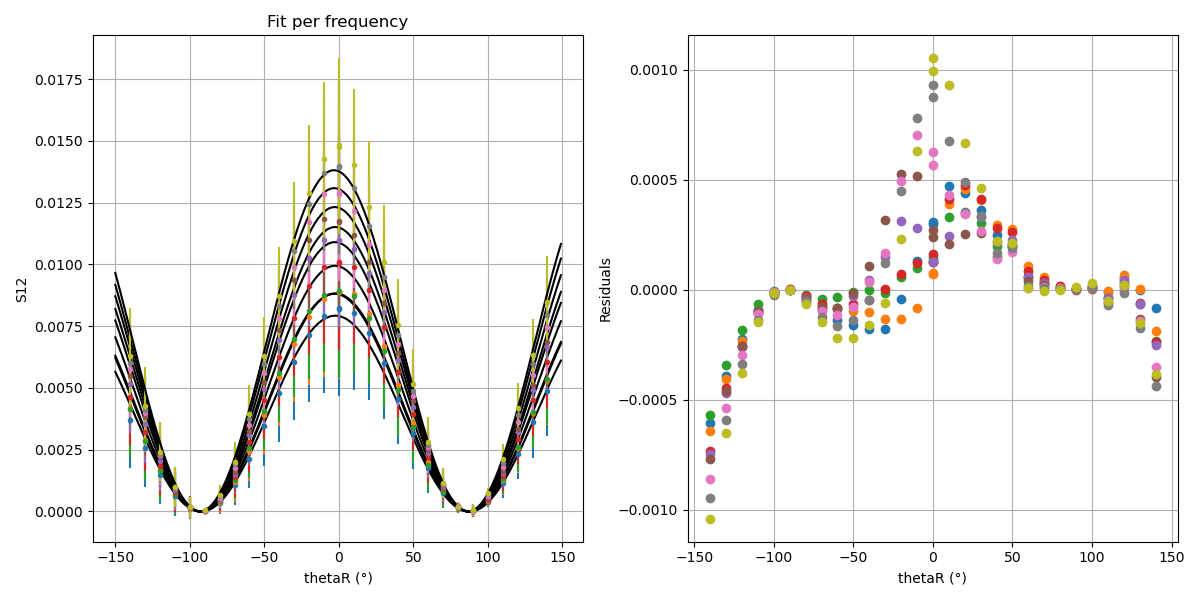

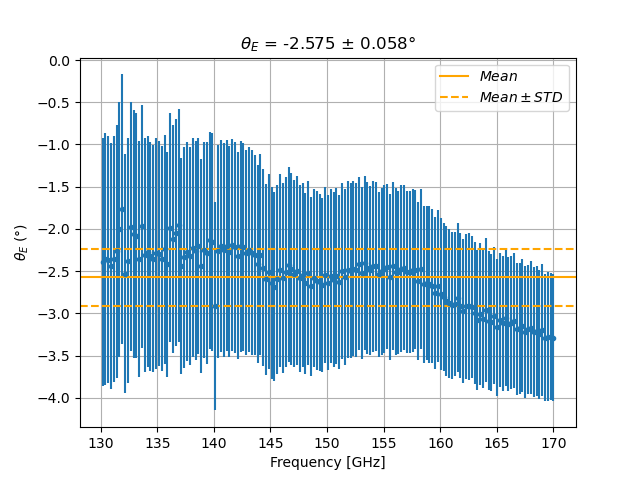

In [61]:
#### With error bars
print("Fitting with error bars")
# Loop over frequencies
t = 1 # trace index (S21 or S12)

allthetaE = []
allthetaE_err = []
allchi2_red = []

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
for f in range(fstart_ind, nfreqs):
    signal = mag_lin[:, t, f]
    sigma = interp_func(fold_angles_180(thetaR))

    # Fit the data
    popt, pcov = curve_fit(cos2, thetaR, signal, sigma=sigma, absolute_sigma=True)
    error = np.sqrt(np.diag(pcov))

    #print("Paramètres optimisés :", popt)
    allthetaE.append(popt[0])
    #print("Erreurs sur les paramètres :", error)
    allthetaE_err.append(error[0])

    # Chi2
    chi2 = get_chi2(signal, cos2(thetaR, *popt), sigma)

    chi2_red = chi2 / (len(thetaR) - len(popt))
    allchi2_red.append(chi2_red)

    residuals = signal - cos2(thetaR, *popt)
    
    if f  in range(fstart_ind, nfreqs, 20): # indices des fréquences à afficher
        axs[0].errorbar(thetaR, signal, yerr=np.abs(sigma), marker='.', ls='None')
        axs[0].plot(tt, cos2(tt, *popt), 'k', label='Fit cos^2')
        axs[0].set_xlabel("thetaR (°)")
        axs[0].set_ylabel(f"{traces[t]}")
        axs[0].set_title(r"Fit per frequency")
        axs[0].grid(10)

        axs[1].plot(thetaR, residuals, 'o', label=f"{freq_samples[f]:.1f}")
        axs[1].set_xlabel("thetaR (°)")
        axs[1].set_ylabel("Residuals")
        axs[1].grid(10)

        fig.tight_layout()


allthetaE = np.array(allthetaE)
allthetaE_err = np.array(allthetaE_err)
allchi2_red = np.array(allchi2_red)

print("All chi2 reduits", allchi2_red)

mthetaE = np.mean(allthetaE)
print("ThetaE moyen :", mthetaE)
stdthetaE = np.std(allthetaE) #/ np.sqrt(nfreqs)
print("Écart-type de thetaE :", stdthetaE)

# Erreur sur la moyenne de thetaE
erreur = np.sqrt(np.sum(allthetaE_err**2 )) / nfreqs
print('Erreur sur thetaE', erreur)

fig = plt.figure()
plt.errorbar(freq_samples[fstart_ind:nfreqs], allthetaE, yerr=allthetaE_err, fmt='.')
plt.axhline(mthetaE, color='orange', label=r'$Mean$')
plt.axhline(mthetaE-stdthetaE, color='orange', ls='--')
plt.axhline(mthetaE+stdthetaE, color='orange', label=r'$Mean \pm STD$', ls='--')
plt.xlabel("Frequency [GHz]")
plt.ylabel(r'$\theta_E$ (°)')
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(mthetaE, erreur))
plt.grid(10)
plt.legend()
#fig.savefig(f"../Plots/Malus_Fit_avec_sigma1e-6_allthetaE", dpi=300)